In [ ]:
import os
# os.environ["CUDA_VISIBLE_DEVICES"]="1"
import torch

# import os
# os.environ["CUDA_VISIBLE_DEVICES"]="1"
torch.cuda.set_device(1)


import numpy as np
import tensorflow as tf
import pandas as pd
import pyarabic.araby as araby
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
import torch
from sklearn.metrics import accuracy_score, f1_score
from transformers import Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset, concatenate_datasets
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 1000)
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.metrics import accuracy_score, f1_score
import numpy as np


log_file = 'log2_bertlstm_13.txt'
with open(log_file, 'w') as f:
    f.write('Model,Accuracy,F1\n')


df = pd.read_json("RE_dataset_Binary_multi_without_F_1.json")



# remove_labels = ["R", "INT", "QU"]  # less than a 100
remove_labels = ["SA", "A", "FT", "R", "INT", "QU"]   # less than 140 samples
df = df[~df["label"].isin(remove_labels)]
df = df.reset_index(drop=True)


df.fillna('', inplace=True)

display(len(df))
display(df[:4])



df = df[df['text'] != '']

classes = set(df['label'].values)
display(classes)

# return

df['label'] = df['label'].astype('category')
df['label'] = df['label'].cat.codes



df = df[['text', 'label']]


classes_num = len(classes)
display(classes_num)
display(len(df))


ds = Dataset.from_pandas(df)

ds = ds.train_test_split(test_size=0.2, seed=42)
display(ds)

max_sequence_length = 128


models = [
    # 'microsoft/deberta-v3-base',
    # 'FacebookAI/roberta-base',
    'bert-base-cased',
]



class BertLSTMModel(nn.Module):
    def __init__(self, model_name, num_labels, hidden_dim=128, num_layers=2):
        super(BertLSTMModel, self).__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        self.lstm = nn.LSTM(input_size=self.bert.config.hidden_size,
                            hidden_size=hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_outputs.last_hidden_state
        lstm_output, _ = self.lstm(sequence_output)
        lstm_output = lstm_output[:, -1, :]  # Take the output of the last time step
        logits = self.classifier(lstm_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
        )




for model_name in models:
    for i in range(3):
        print(f'{model_name}-lstm, try:{i}')

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = BertLSTMModel(model_name=model_name, num_labels=classes_num).to('cuda')

        dataset_train = ds['train']
        dataset_validation = ds['test']

        def preprocess_function(examples):
            return tokenizer(examples['text'], truncation=True, padding="max_length",
                             max_length=max_sequence_length, add_special_tokens=True)

        dataset_train = dataset_train.map(preprocess_function, batched=True)
        dataset_validation = dataset_validation.map(preprocess_function, batched=True)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            predictions = np.argmax(logits, axis=-1)
            acc = accuracy_score(labels, predictions)
            f1 = f1_score(labels, predictions, average='micro')
            with open(log_file, 'a') as f:
                f.write(f'{model_name}-lstm,{acc},{f1}\n')
            return {'accuracy': acc, 'f1_score': f1}

        epochs = 25
        save_steps = 10000
        batch_size = 32

        training_args = TrainingArguments(
            output_dir='bert/',
            overwrite_output_dir=True,
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            save_steps=save_steps,
            save_total_limit=1,
            fp16=True,
            learning_rate=5e-5,
            logging_steps=50,
            evaluation_strategy='steps',
            eval_steps=50
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=dataset_train,
            eval_dataset=dataset_validation,
            compute_metrics=compute_metrics
        )

        trainer.train()



results = pd.read_csv(log_file)

best_results = results.groupby('Model', as_index=False)['F1'].max()

best_results = pd.merge(best_results, results, on=['Model', 'F1'])
best_results = best_results[['Model', 'Accuracy', 'F1']]
best_results = best_results.drop_duplicates()
best_results.to_csv('results_bertlstm_13.csv')
display(best_results)



2025-09-20 12:04:28.238599: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-20 12:04:28.385483: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-20 12:04:29.161955: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


1799

,label,text
0,CO,The Libra scheduler will be a sub-component of SGE.
1,O,All coding will be done in standard C
2,CO,Exhaustive searches of the entire set of combinations of jobs will not be done. Heuristics will be developed for this scheduling problem.
3,CO,The Clarus system shall be able to be hosted at one or more physical locations.


{'CO', 'MN', 'O', 'PE', 'PO', 'SE', 'US'}

7

...

bert-base-cased-lstm, try:2


Map:   0%|          | 0/1439 [00:00<?, ? examples/s]

Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Accuracy,F1 Score
50,1.602600,1.250965,0.705556,0.705556
100,0.973900,0.876878,0.791667,0.791667
150,0.556100,0.721745,0.805556,0.805556
200,0.308500,0.637144,0.833333,0.833333
250,0.201400,0.625794,0.836111,0.836111
300,0.124400,0.589168,0.841667,0.841667
350,0.085100,0.792450,0.802778,0.802778
400,0.066300,0.551853,0.852778,0.852778
450,0.033300,0.465061,0.877778,0.877778
500,0.026100,0.459846,0.886111,0.886111


,Model,Accuracy,F1
0,bert-base-cased-lstm,0.894444,0.894444


{0: 'CO', 1: 'MN', 2: 'O', 3: 'PE', 4: 'PO', 5: 'SE', 6: 'US'}

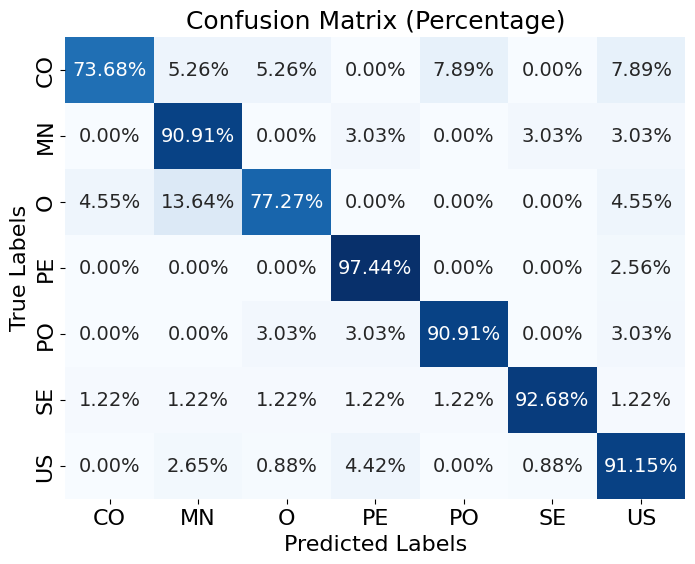

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


df = pd.read_json("RE_dataset_Binary_multi_without_F_1.json")

remove_labels = ["SA", "A", "FT", "R", "INT", "QU"]   # less than 140 samples
df = df[~df["label"].isin(remove_labels)]
df = df.reset_index(drop=True)



df['label'] = df['label'].astype('category')
df['label_name'] = df['label']
df['label'] = df['label'].cat.codes

label_mapping = dict(enumerate(df['label_name'].astype('category').cat.categories))
display(label_mapping)
print()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for sample in dataset_validation:

        inputs = tokenizer(sample['text'], truncation=True, padding="max_length",
                                   max_length=max_sequence_length, return_tensors="pt").to('cuda')

        true_label = sample['label']
        true_labels.append(true_label)

        if 'token_type_ids' in inputs:
                    inputs.pop('token_type_ids')
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
        predicted_labels.append(prediction)

labels = [label_mapping[i] for i in range(len(label_mapping))]

cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1, 2, 3, 4, 5, 6])

cm_percentage = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percentage, annot=True, fmt='.2%', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title('Confusion Matrix (Percentage)', fontsize=18)
plt.xlabel('Predicted Labels', fontsize=16)
plt.ylabel('True Labels', fontsize=16)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

# true_labels and predicted_labels already collected in your loop
# label_mapping is {0: 'CO', 1: 'US', ...}

# Create ordered list of classes
target_names = [label_mapping[i] for i in range(len(label_mapping))]

# Generate report
report = classification_report(
    true_labels,
    predicted_labels,
    labels=list(label_mapping.keys()),
    target_names=target_names,
    digits=4  # control decimal places
)

print(report)


              precision    recall  f1-score   support

          CO     0.9333    0.7368    0.8235        38
          MN     0.7692    0.9091    0.8333        33
           O     0.7727    0.7727    0.7727        22
          PE     0.8261    0.9744    0.8941        39
          PO     0.8824    0.9091    0.8955        33
          SE     0.9744    0.9268    0.9500        82
          US     0.9279    0.9115    0.9196       113

    accuracy                         0.8944       360
   macro avg     0.8694    0.8772    0.8698       360
weighted avg     0.8998    0.8944    0.8945       360

